In [1]:
import pandas as pd

In [2]:
borrowers = pd.read_csv("borrowers.csv")

In [3]:
collateral = pd.read_csv("collateral.csv")

In [4]:
credit_history = pd.read_csv("credit_history.csv")

In [5]:
loan_payments = pd.read_csv("loan_payments.csv")

In [6]:
loan = pd.read_csv("loans.csv")

## 1. Check shape

In [7]:
print("Borrowers:", borrowers.shape)
print("Loans:", loan.shape)
print("Loan Payments:", loan_payments.shape)
print("Credit History:", credit_history.shape)
print("Collateral:", collateral.shape)

Borrowers: (1200, 9)
Loans: (1800, 11)
Loan Payments: (36088, 8)
Credit History: (1200, 6)
Collateral: (1800, 3)


## 2. Check column names

In [8]:
print("Borrowers columns:")
print(borrowers.columns.tolist())

print("\nLoans columns:")
print(loan.columns.tolist())

print("\nLoan Payments columns:")
print(loan_payments.columns.tolist())

print("\nCredit History columns:")
print(credit_history.columns.tolist())

print("\nCollateral columns:")
print(collateral.columns.tolist())

Borrowers columns:
['borrower_id', 'application_date', 'age', 'employment_type', 'region', 'annual_income', 'dependents', 'credit_score', 'existing_debt']

Loans columns:
['loan_id', 'borrower_id', 'application_date', 'loan_type', 'loan_amount', 'term_months', 'interest_rate', 'loan_status', 'default_flag', 'application_channel', 'disbursement_date']

Loan Payments columns:
['payment_id', 'loan_id', 'borrower_id', 'due_date', 'payment_date', 'scheduled_principal', 'payment_status', 'days_past_due']

Credit History columns:
['borrower_id', 'open_accounts', 'delinquent_accounts', 'credit_history_years', 'recent_inquiries', 'credit_utilization']

Collateral columns:
['loan_id', 'collateral_type', 'collateral_value']


## 3. Check data types

In [9]:
print("=== Borrowers ===")
print(borrowers.dtypes)

print("\n=== Loans ===")
print(loan.dtypes)

print("\n=== Loan Payments ===")
print(loan_payments.dtypes)

print("\n=== Credit History ===")
print(credit_history.dtypes)

print("\n=== Collateral ===")
print(collateral.dtypes)

=== Borrowers ===
borrower_id           str
application_date      str
age                 int64
employment_type       str
region                str
annual_income       int64
dependents          int64
credit_score        int64
existing_debt       int64
dtype: object

=== Loans ===
loan_id                    str
borrower_id                str
application_date           str
loan_type                  str
loan_amount              int64
term_months              int64
interest_rate          float64
loan_status                str
default_flag             int64
application_channel        str
disbursement_date          str
dtype: object

=== Loan Payments ===
payment_id                 str
loan_id                    str
borrower_id                str
due_date                   str
payment_date               str
scheduled_principal    float64
payment_status             str
days_past_due          float64
dtype: object

=== Credit History ===
borrower_id                 str
open_accounts          

## 4. Check missing values

In [10]:
print("=== Missing Values ===")

print("\nBorrowers:")
print(borrowers.isna().sum())

print("\nLoans:")
print(loan.isna().sum())

print("\nLoan Payments:")
print(loan_payments.isna().sum())

print("\nCredit History:")
print(credit_history.isna().sum())

print("\nCollateral:")
print(collateral.isna().sum())

=== Missing Values ===

Borrowers:
borrower_id         0
application_date    0
age                 0
employment_type     0
region              0
annual_income       0
dependents          0
credit_score        0
existing_debt       0
dtype: int64

Loans:
loan_id                0
borrower_id            0
application_date       0
loan_type              0
loan_amount            0
term_months            0
interest_rate          0
loan_status            0
default_flag           0
application_channel    0
disbursement_date      0
dtype: int64

Loan Payments:
payment_id               0
loan_id                  0
borrower_id              0
due_date                 0
payment_date           392
scheduled_principal      0
payment_status           0
days_past_due          392
dtype: int64

Credit History:
borrower_id             0
open_accounts           0
delinquent_accounts     0
credit_history_years    0
recent_inquiries        0
credit_utilization      0
dtype: int64

Collateral:
loan_id       

In [11]:
print("\n=== Unique Values ===")

print("\nLoan Types:")
print(loan["loan_type"].unique())

print("\nLoan Status:")
print(loan["loan_status"].unique())

print("\nApplication Channels:")
print(loan["application_channel"].unique())

print("\nEmployment Types:")
print(borrowers["employment_type"].unique())

print("\nRegions:")
print(borrowers["region"].unique())

print("\nPayment Status:")
print(loan_payments["payment_status"].unique())


=== Unique Values ===

Loan Types:
<StringArray>
[        'Personal', 'Home Improvement',             'Auto',
        'Education',   'Small Business',        'Personal ']
Length: 6, dtype: str

Loan Status:
<StringArray>
['Active', 'Defaulted', 'Closed', ' active']
Length: 4, dtype: str

Application Channels:
<StringArray>
['Online', 'Branch', ' Online ', 'Mobile App', 'Partner', 'mobile app']
Length: 6, dtype: str

Employment Types:
<StringArray>
['Salaried', 'Self-Employed', 'Contract', 'Business Owner']
Length: 4, dtype: str

Regions:
<StringArray>
['North', 'South', 'East', 'West']
Length: 4, dtype: str

Payment Status:
<StringArray>
['On Time', 'Late', 'Missed', 'Delinquent']
Length: 4, dtype: str


## Data Type Conversion & Date Validation

In [11]:
# Convert date columns to datetime

borrowers["application_date"] = pd.to_datetime(
    borrowers["application_date"]
)

loan["application_date"] = pd.to_datetime(
    loan["application_date"]
)

loan["disbursement_date"] = pd.to_datetime(
    loan["disbursement_date"]
)

loan_payments["due_date"] = pd.to_datetime(
    loan_payments["due_date"]
)

loan_payments["payment_date"] = pd.to_datetime(
    loan_payments["payment_date"]
)

In [12]:
print("=== Date Data Types ===")

print("\nBorrowers:")
print(borrowers["application_date"].dtype)

print("\nLoans:")
print(loan[["application_date", "disbursement_date"]].dtypes)

print("\nLoan Payments:")
print(loan_payments[["due_date", "payment_date"]].dtypes)

=== Date Data Types ===

Borrowers:
datetime64[us]

Loans:
application_date     datetime64[us]
disbursement_date    datetime64[us]
dtype: object

Loan Payments:
due_date        datetime64[us]
payment_date    datetime64[us]
dtype: object


In [13]:
print("=== Date Ranges ===")

print(
    "Borrower application:",
    borrowers["application_date"].min(),
    "to",
    borrowers["application_date"].max()
)

print(
    "Loan application:",
    loan["application_date"].min(),
    "to",
    loan["application_date"].max()
)

print(
    "Loan disbursement:",
    loan["disbursement_date"].min(),
    "to",
    loan["disbursement_date"].max()
)

print(
    "Payment due date:",
    loan_payments["due_date"].min(),
    "to",
    loan_payments["due_date"].max()
)

=== Date Ranges ===
Borrower application: 2021-01-01 00:00:00 to 2025-12-05 00:00:00
Loan application: 2024-01-01 00:00:00 to 2025-12-30 00:00:00
Loan disbursement: 2024-01-04 00:00:00 to 2026-01-11 00:00:00
Payment due date: 2024-02-04 00:00:00 to 2028-01-11 00:00:00


In [14]:
# Check invalid date sequences

print("=== Invalid Date Sequences ===")

# Loan disbursement before loan application
invalid_disbursement = loan[
    loan["disbursement_date"] < loan["application_date"]
]

print(
    "Disbursement before application:",
    len(invalid_disbursement)
)

# Payment due date before loan disbursement
payment_loan = loan_payments.merge(
    loan[["loan_id", "disbursement_date"]],
    on="loan_id",
    how="left"
)

invalid_due_date = payment_loan[
    payment_loan["due_date"] < payment_loan["disbursement_date"]
]

print(
    "Payment due date before disbursement:",
    len(invalid_due_date)
)

# Payment date before due date
invalid_payment_date = loan_payments[
    loan_payments["payment_date"].notna() &
    (loan_payments["payment_date"] < loan_payments["due_date"])
]

print(
    "Payment date before due date:",
    len(invalid_payment_date)
)

=== Invalid Date Sequences ===
Disbursement before application: 0
Payment due date before disbursement: 0
Payment date before due date: 0


In [15]:
print("=== Numeric Data Quality Checks ===")

# Borrowers
print(
    "Negative annual income:",
    (borrowers["annual_income"] < 0).sum()
)

print(
    "Negative existing debt:",
    (borrowers["existing_debt"] < 0).sum()
)

print(
    "Invalid credit scores:",
    (
        (borrowers["credit_score"] < 300) |
        (borrowers["credit_score"] > 850)
    ).sum()
)

print(
    "Negative dependents:",
    (borrowers["dependents"] < 0).sum()
)


# Loans
print(
    "Negative loan amounts:",
    (loan["loan_amount"] < 0).sum()
)

print(
    "Invalid loan terms:",
    (loan["term_months"] <= 0).sum()
)

print(
    "Invalid interest rates:",
    (loan["interest_rate"] < 0).sum()
)


# Loan Payments
print(
    "Negative scheduled principal:",
    (loan_payments["scheduled_principal"] < 0).sum()
)

print(
    "Negative days past due:",
    (loan_payments["days_past_due"] < 0).sum()
)


# Credit History
print(
    "Negative open accounts:",
    (credit_history["open_accounts"] < 0).sum()
)

print(
    "Negative delinquent accounts:",
    (credit_history["delinquent_accounts"] < 0).sum()
)

print(
    "Negative recent inquiries:",
    (credit_history["recent_inquiries"] < 0).sum()
)

print(
    "Invalid credit utilization:",
    (
        (credit_history["credit_utilization"] < 0) |
        (credit_history["credit_utilization"] > 1)
    ).sum()
)


# Collateral
print(
    "Negative collateral value:",
    (collateral["collateral_value"] < 0).sum()
)

=== Numeric Data Quality Checks ===
Negative annual income: 0
Negative existing debt: 0
Invalid credit scores: 0
Negative dependents: 0
Negative loan amounts: 0
Invalid loan terms: 0
Invalid interest rates: 0
Negative scheduled principal: 0
Negative days past due: 0
Negative open accounts: 0
Negative delinquent accounts: 0
Negative recent inquiries: 0
Invalid credit utilization: 0
Negative collateral value: 0


In [16]:
print("=== Numeric Data Quality Checks ===")

# Borrowers
print(
    "Negative annual income:",
    (borrowers["annual_income"] < 0).sum()
)

print(
    "Negative existing debt:",
    (borrowers["existing_debt"] < 0).sum()
)

print(
    "Invalid credit scores:",
    (
        (borrowers["credit_score"] < 300) |
        (borrowers["credit_score"] > 850)
    ).sum()
)

print(
    "Negative dependents:",
    (borrowers["dependents"] < 0).sum()
)


# Loans
print(
    "Negative loan amounts:",
    (loan["loan_amount"] < 0).sum()
)

print(
    "Invalid loan terms:",
    (loan["term_months"] <= 0).sum()
)

print(
    "Invalid interest rates:",
    (loan["interest_rate"] < 0).sum()
)


# Loan Payments
print(
    "Negative scheduled principal:",
    (loan_payments["scheduled_principal"] < 0).sum()
)

print(
    "Negative days past due:",
    (loan_payments["days_past_due"] < 0).sum()
)


# Credit History
print(
    "Negative open accounts:",
    (credit_history["open_accounts"] < 0).sum()
)

print(
    "Negative delinquent accounts:",
    (credit_history["delinquent_accounts"] < 0).sum()
)

print(
    "Negative recent inquiries:",
    (credit_history["recent_inquiries"] < 0).sum()
)

print(
    "Invalid credit utilization:",
    (
        (credit_history["credit_utilization"] < 0) |
        (credit_history["credit_utilization"] > 1)
    ).sum()
)


# Collateral
print(
    "Negative collateral value:",
    (collateral["collateral_value"] < 0).sum()
)

=== Numeric Data Quality Checks ===
Negative annual income: 0
Negative existing debt: 0
Invalid credit scores: 0
Negative dependents: 0
Negative loan amounts: 0
Invalid loan terms: 0
Invalid interest rates: 0
Negative scheduled principal: 0
Negative days past due: 0
Negative open accounts: 0
Negative delinquent accounts: 0
Negative recent inquiries: 0
Invalid credit utilization: 0
Negative collateral value: 0


## Check Categorical Data Quality

In [17]:
print("=== Categorical Data Quality Checks ===")

print("\nLoan Types:")
print(loan["loan_type"].value_counts())

print("\nLoan Status:")
print(loan["loan_status"].value_counts())

print("\nApplication Channels:")
print(loan["application_channel"].value_counts())

print("\nEmployment Types:")
print(borrowers["employment_type"].value_counts())

print("\nRegions:")
print(borrowers["region"].value_counts())

print("\nPayment Status:")
print(loan_payments["payment_status"].value_counts())

print("\nCollateral Types:")
print(collateral["collateral_type"].value_counts(dropna=False))

=== Categorical Data Quality Checks ===

Loan Types:
loan_type
Personal            718
Auto                374
Home Improvement    310
Small Business      227
Education           170
Personal              1
Name: count, dtype: int64

Loan Status:
loan_status
Active       813
Closed       594
Defaulted    392
 active        1
Name: count, dtype: int64

Application Channels:
application_channel
Online        750
Branch        439
Mobile App    417
Partner       192
 Online         1
mobile app      1
Name: count, dtype: int64

Employment Types:
employment_type
Salaried          696
Self-Employed     240
Business Owner    161
Contract          103
Name: count, dtype: int64

Regions:
region
North    321
East     303
South    294
West     282
Name: count, dtype: int64

Payment Status:
payment_status
On Time       26828
Late           8151
Delinquent      717
Missed          392
Name: count, dtype: int64

Collateral Types:
collateral_type
NaN         1116
Vehicle      374
Property     310
Na

In [18]:
print("=== Cleaning Categorical Values ===")

# Loan Type
loan["loan_type"] = loan["loan_type"].str.strip()

# Loan Status
loan["loan_status"] = loan["loan_status"].str.strip().str.title()

# Application Channel
loan["application_channel"] = (
    loan["application_channel"]
    .str.strip()
    .str.title()
)

print("\n=== After Cleaning ===")

print("\nLoan Types:")
print(loan["loan_type"].value_counts())

print("\nLoan Status:")
print(loan["loan_status"].value_counts())

print("\nApplication Channels:")
print(loan["application_channel"].value_counts())

=== Cleaning Categorical Values ===

=== After Cleaning ===

Loan Types:
loan_type
Personal            719
Auto                374
Home Improvement    310
Small Business      227
Education           170
Name: count, dtype: int64

Loan Status:
loan_status
Active       814
Closed       594
Defaulted    392
Name: count, dtype: int64

Application Channels:
application_channel
Online        751
Branch        439
Mobile App    418
Partner       192
Name: count, dtype: int64


## Check Duplicate Records

In [19]:
print("=== Duplicate Record Checks ===")

print(
    "Borrowers - duplicate rows:",
    borrowers.duplicated().sum()
)

print(
    "Loans - duplicate rows:",
    loan.duplicated().sum()
)

print(
    "Loan Payments - duplicate rows:",
    loan_payments.duplicated().sum()
)

print(
    "Credit History - duplicate rows:",
    credit_history.duplicated().sum()
)

print(
    "Collateral - duplicate rows:",
    collateral.duplicated().sum()
)


print("\n=== Duplicate Primary Keys ===")

print(
    "Borrower IDs:",
    borrowers["borrower_id"].duplicated().sum()
)

print(
    "Loan IDs:",
    loan["loan_id"].duplicated().sum()
)

print(
    "Payment IDs:",
    loan_payments["payment_id"].duplicated().sum()
)

print(
    "Credit History Borrower IDs:",
    credit_history["borrower_id"].duplicated().sum()
)

print(
    "Collateral Loan IDs:",
    collateral["loan_id"].duplicated().sum()
)

=== Duplicate Record Checks ===
Borrowers - duplicate rows: 0
Loans - duplicate rows: 0
Loan Payments - duplicate rows: 0
Credit History - duplicate rows: 0
Collateral - duplicate rows: 0

=== Duplicate Primary Keys ===
Borrower IDs: 0
Loan IDs: 0
Payment IDs: 0
Credit History Borrower IDs: 0
Collateral Loan IDs: 0


## 5. Check duplicate primary keys

In [20]:
print("Duplicate borrower IDs:",
      borrowers["borrower_id"].duplicated().sum())

print("Duplicate loan IDs:",
      loan["loan_id"].duplicated().sum())

print("Duplicate payment IDs:",
      loan_payments["payment_id"].duplicated().sum())

print("Duplicate credit-history borrower IDs:",
      credit_history["borrower_id"].duplicated().sum())

print("Duplicate collateral loan IDs:",
      collateral["loan_id"].duplicated().sum())

Duplicate borrower IDs: 0
Duplicate loan IDs: 0
Duplicate payment IDs: 0
Duplicate credit-history borrower IDs: 0
Duplicate collateral loan IDs: 0


## 6. Inspect the first few records

In [21]:
display(borrowers.head())
display(loan.head())
display(loan_payments.head())
display(credit_history.head())
display(collateral.head())

,borrower_id,application_date,age,employment_type,region,annual_income,dependents,credit_score,existing_debt
0,B100001,2024-02-01,31,Salaried,North,94700,0,707,63300
1,B100002,2024-12-30,24,Self-Employed,South,189600,2,762,157000
2,B100003,2023-05-11,35,Salaried,East,100400,2,546,75000
3,B100004,2024-07-18,26,Self-Employed,West,33100,3,664,50700
4,B100005,2024-02-05,50,Contract,West,74300,2,719,47500


,loan_id,borrower_id,application_date,loan_type,loan_amount,term_months,interest_rate,loan_status,default_flag,application_channel,disbursement_date
0,L200001,B100922,2025-02-19,Personal,128000,36,6.85,Active,0,Online,2025-02-26
1,L200002,B100662,2025-01-11,Home Improvement,38100,24,8.47,Active,0,Online,2025-01-13
2,L200003,B100405,2025-04-07,Auto,99800,36,11.98,Defaulted,1,Online,2025-04-17
3,L200004,B100677,2025-10-22,Education,74100,12,7.86,Active,0,Branch,2025-10-24
4,L200005,B100589,2024-05-25,Small Business,320900,36,7.16,Closed,0,Online,2024-06-07


,payment_id,loan_id,borrower_id,due_date,payment_date,scheduled_principal,payment_status,days_past_due
0,P500001,L200001,B100922,2025-03-26,2025-03-26,5333.33,On Time,0.0
1,P500002,L200001,B100922,2025-04-26,2025-04-26,5333.33,On Time,0.0
2,P500003,L200001,B100922,2025-05-26,2025-05-26,5333.33,On Time,0.0
3,P500004,L200001,B100922,2025-06-26,2025-06-26,5333.33,On Time,0.0
4,P500005,L200001,B100922,2025-07-26,2025-07-26,5333.33,On Time,0.0


,borrower_id,open_accounts,delinquent_accounts,credit_history_years,recent_inquiries,credit_utilization
0,B100001,2,1,21.2,0,0.328
1,B100002,5,0,21.1,4,0.172
2,B100003,10,0,25.8,2,0.330
3,B100004,4,0,27.5,1,0.903
4,B100005,2,0,11.4,1,0.395


,loan_id,collateral_type,collateral_value
0,L200001,NaN,0
1,L200002,Property,51900
2,L200003,Vehicle,141200
3,L200004,NaN,0
4,L200005,NaN,0


In [22]:
borrowers[
    borrowers["borrower_id"] == "B999999"
]

,borrower_id,application_date,age,employment_type,region,annual_income,dependents,credit_score,existing_debt


In [23]:
loans_clean = loan[
    loan["borrower_id"].isin(borrowers["borrower_id"])
].copy()

In [24]:
print("Original loans:", len(loan))
print("Clean loans:", len(loans_clean))

print(
    "Orphan borrowers after cleaning:",
    (~loans_clean["borrower_id"].isin(
        borrowers["borrower_id"]
    )).sum()
)

Original loans: 1800
Clean loans: 1799
Orphan borrowers after cleaning: 0


In [25]:
print("Collateral:", len(collateral))
print("Unique collateral loan IDs:",
      collateral["loan_id"].nunique())

print(
    "Collateral loan IDs not in cleaned loans:",
    (~collateral["loan_id"].isin(loans_clean["loan_id"])).sum()
)

Collateral: 1800
Unique collateral loan IDs: 1800
Collateral loan IDs not in cleaned loans: 1


In [26]:
orphan_collateral = collateral[
    ~collateral["loan_id"].isin(loans_clean["loan_id"])
]

display(orphan_collateral)

,loan_id,collateral_type,collateral_value
41,L200042,Vehicle,681700


In [27]:
collateral_clean = collateral[
    collateral["loan_id"].isin(loans_clean["loan_id"])
].copy()

In [28]:
print("Original collateral:", len(collateral))
print("Clean collateral:", len(collateral_clean))

print(
    "Orphan collateral after cleaning:",
    (~collateral_clean["loan_id"].isin(
        loans_clean["loan_id"]
    )).sum()
)

Original collateral: 1800
Clean collateral: 1799
Orphan collateral after cleaning: 0


## Pandas data-quality validation.

## 1. Check invalid loan amounts

In [29]:
print("Non-positive loan amounts:",
      (loans_clean["loan_amount"] <= 0).sum())

print("Non-positive scheduled principal:",
      (loan_payments["scheduled_principal"] <= 0).sum())

print("Non-positive annual income:",
      (borrowers["annual_income"] <= 0).sum())

Non-positive loan amounts: 0
Non-positive scheduled principal: 0
Non-positive annual income: 0


## 2. Check invalid credit scores

In [30]:
invalid_credit_scores = borrowers[(borrowers["credit_score"]<300) | (borrowers["credit_score"]>850)]
print("Invalid credit scores:",
      len(invalid_credit_scores))

display(invalid_credit_scores)

Invalid credit scores: 0


,borrower_id,application_date,age,employment_type,region,annual_income,dependents,credit_score,existing_debt


## 3. Check payment dates before due dates

In [31]:
payment_date_errors = loan_payments[
    loan_payments["payment_date"].notna() &
    (loan_payments["payment_date"] < loan_payments["due_date"])
]

print("Payment dates before due dates:",
      len(payment_date_errors))

display(payment_date_errors.head())

Payment dates before due dates: 0


,payment_id,loan_id,borrower_id,due_date,payment_date,scheduled_principal,payment_status,days_past_due


## 4. Check loan disbursement before application

In [32]:
disbursement_errors = loans_clean[
    loans_clean["disbursement_date"].notna() &
    (loans_clean["disbursement_date"] <
     loans_clean["application_date"])
]

print("Disbursement before application:",
      len(disbursement_errors))

display(disbursement_errors)

Disbursement before application: 0


,loan_id,borrower_id,application_date,loan_type,loan_amount,term_months,interest_rate,loan_status,default_flag,application_channel,disbursement_date


## 5. Check loan application before borrower application

In [33]:
application_errors = loans_clean.merge(
    borrowers[
        ["borrower_id", "application_date"]
    ],
    on="borrower_id",
    suffixes=("_loan", "_borrower")
)

application_errors = application_errors[
    application_errors["application_date_loan"] <
    application_errors["application_date_borrower"]
]

print("Loan application before borrower application:",
      len(application_errors))

display(application_errors.head())

Loan application before borrower application: 335


,loan_id,borrower_id,application_date_loan,loan_type,loan_amount,term_months,interest_rate,loan_status,default_flag,application_channel,disbursement_date,application_date_borrower
8,L200009,B100479,2024-10-12,Personal,148000,48,7.34,Closed,0,Branch,2024-10-21,2025-03-10
13,L200014,B101030,2024-05-13,Personal,255500,60,6.00,Closed,0,Online,2024-05-26,2025-01-13
18,L200019,B100686,2024-10-12,Personal,413700,36,9.09,Defaulted,1,Branch,2024-10-21,2025-04-21
21,L200022,B100940,2024-10-23,Personal,78500,12,6.00,Active,0,Mobile App,2024-10-30,2024-12-31
25,L200026,B100538,2025-05-11,Personal,166800,12,9.96,Active,0,Mobile App,2025-05-22,2025-08-21


## 6. Check collateral values

In [34]:
negative_collateral = collateral_clean[
    collateral_clean["collateral_value"] < 0
]

print("Negative collateral values:",
      len(negative_collateral))

display(negative_collateral.head())

Negative collateral values: 0


,loan_id,collateral_type,collateral_value


## Clean categorical fields

## 1. Borrowers - categorical columns

In [35]:
borrowers["employment_type_raw"] = borrowers["employment_type"]
borrowers["region_raw"] = borrowers["region"]

In [36]:
borrowers["employment_type"] = (
    borrowers["employment_type"]
    .str.strip()
    .str.title()
)

borrowers["region"] = (
    borrowers["region"]
    .str.strip()
    .str.title()
)

In [29]:
print("Employment Type:")
print(borrowers["employment_type"].value_counts(dropna=False))

print("\nRegion:")
print(borrowers["region"].value_counts(dropna=False))

Employment Type:
employment_type
Salaried          696
Self-Employed     240
Business Owner    161
Contract          103
Name: count, dtype: int64

Region:
region
North    321
East     303
South    294
West     282
Name: count, dtype: int64


## 2. Loans — categorical columns

In [37]:
loans_clean["loan_type_raw"] = loans_clean["loan_type"]
loans_clean["loan_status_raw"] = loans_clean["loan_status"]
loans_clean["application_channel_raw"] = loans_clean["application_channel"]

In [38]:
loans_clean["loan_type"] = (
    loans_clean["loan_type"]
    .str.strip()
    .str.title()
)

loans_clean["loan_status"] = (
    loans_clean["loan_status"]
    .str.strip()
    .str.title()
)

loans_clean["application_channel"] = (
    loans_clean["application_channel"]
    .str.strip()
    .str.title()
)

In [32]:
print("Loan Type:")
print(loans_clean["loan_type"].value_counts(dropna=False))

print("\nLoan Status:")
print(loans_clean["loan_status"].value_counts(dropna=False))

print("\nApplication Channel:")
print(loans_clean["application_channel"].value_counts(dropna=False))

Loan Type:
loan_type
Personal            719
Auto                373
Home Improvement    310
Small Business      227
Education           170
Name: count, dtype: int64

Loan Status:
loan_status
Active       814
Closed       594
Defaulted    391
Name: count, dtype: int64

Application Channel:
application_channel
Online        751
Branch        439
Mobile App    417
Partner       192
Name: count, dtype: int64


## 3. Loan payments

In [39]:
loan_payments["payment_status_raw"] = loan_payments["payment_status"]

In [40]:
loan_payments["payment_status"] = (
    loan_payments["payment_status"]
    .str.strip()
    .str.title()
)

In [41]:
print(
    loan_payments["payment_status"]
    .value_counts(dropna=False)
)

payment_status
On Time       26828
Late           8151
Delinquent      717
Missed          392
Name: count, dtype: int64


## 4. Collateral

In [42]:
collateral_clean["collateral_type_raw"] = (
    collateral_clean["collateral_type"]
)

In [43]:
collateral_clean["collateral_type"] = (
    collateral_clean["collateral_type"]
    .str.strip()
    .str.title()
)

In [44]:
print(
    collateral_clean["collateral_type"]
    .value_counts(dropna=False)
)

collateral_type
NaN         1116
Vehicle      373
Property     310
Name: count, dtype: int64


## 5.Validate controlled categories

In [45]:
valid_employment = {
    "Business Owner",
    "Contract",
    "Salaried",
    "Self-Employed"
}

print(
    "Invalid employment types:",
    sorted(
        set(borrowers["employment_type"].dropna())
        - valid_employment
    )
)

Invalid employment types: []


In [46]:
valid_regions = {
    "North",
    "South",
    "East",
    "West"
}

print(
    "Invalid regions:",
    sorted(
        set(borrowers["region"].dropna())
        - valid_regions
    )
)

Invalid regions: []


In [47]:
valid_status = {
    "Active",
    "Closed",
    "Defaulted"
}

print(
    "Invalid loan statuses:",
    sorted(
        set(loans_clean["loan_status"].dropna())
        - valid_status
    )
)

Invalid loan statuses: []


In [48]:
valid_channels = {
    "Online",
    "Mobile App",
    "Branch",
    "Partner"
}

print(
    "Invalid application channels:",
    sorted(
        set(loans_clean["application_channel"].dropna())
        - valid_channels
    )
)

Invalid application channels: []


In [43]:
valid_payment_status = {
    "On Time",
    "Late",
    "Missed",
    "Delinquent"
}

print(
    "Invalid payment statuses:",
    sorted(
        set(loan_payments["payment_status"].dropna())
        - valid_payment_status
    )
)

Invalid payment statuses: []


## 5 - Convert dates

In [49]:
# Convert date columns to datetime

borrowers["application_date"] = pd.to_datetime(
    borrowers["application_date"],
    errors="coerce"
)

loan["application_date"] = pd.to_datetime(
    loan["application_date"],
    errors="coerce"
)

loan["disbursement_date"] = pd.to_datetime(
    loan["disbursement_date"],
    errors="coerce"
)

loan_payments["due_date"] = pd.to_datetime(
    loan_payments["due_date"],
    errors="coerce"
)

loan_payments["payment_date"] = pd.to_datetime(
    loan_payments["payment_date"],
    errors="coerce"
)

In [50]:
loans_clean["application_date"] = pd.to_datetime(
    loans_clean["application_date"],
    errors="coerce"
)

loans_clean["disbursement_date"] = pd.to_datetime(
    loans_clean["disbursement_date"],
    errors="coerce"
)

In [51]:
loans_clean["application_to_disbursement_days"] = (
    loans_clean["disbursement_date"]
    - loans_clean["application_date"]
).dt.days

In [52]:
print(loans_clean[
    ["application_date", "disbursement_date"]
].dtypes)

application_date     datetime64[us]
disbursement_date    datetime64[us]
dtype: object


In [53]:
display(
    loans_clean[
        [
            "loan_id",
            "application_date",
            "disbursement_date",
            "application_to_disbursement_days"
        ]
    ].head()
)

,loan_id,application_date,disbursement_date,application_to_disbursement_days
0,L200001,2025-02-19,2025-02-26,7
1,L200002,2025-01-11,2025-01-13,2
2,L200003,2025-04-07,2025-04-17,10
3,L200004,2025-10-22,2025-10-24,2
4,L200005,2024-05-25,2024-06-07,13


In [54]:
print(
    loans_clean["application_to_disbursement_days"].describe()
)

count    1799.000000
mean        7.554753
std         4.010023
min         1.000000
25%         4.000000
50%         7.000000
75%        11.000000
max        14.000000
Name: application_to_disbursement_days, dtype: float64


In [55]:
print(
    "Negative application-to-disbursement days:",
    (
        loans_clean["application_to_disbursement_days"] < 0
    ).sum()
)

Negative application-to-disbursement days: 0


In [56]:
loans_clean = loan[
    loan["borrower_id"].isin(borrowers["borrower_id"])
].copy()

In [57]:
loans_clean["loan_status"] = (
    loans_clean["loan_status"]
    .str.strip()
    .str.title()
)

In [58]:
loan_status_counts = (
    loans_clean["loan_status"]
    .value_counts()
    .rename_axis("loan_status")
    .reset_index(name="loan_count")
)

loan_status_counts

,loan_status,loan_count
0,Active,814
1,Closed,594
2,Defaulted,391


## 6.Create risk features

## 1.Debt-to-income ratio

In [59]:
borrowers["debt_to_income"] = (
    borrowers["existing_debt"] /
    borrowers["annual_income"]
)

In [60]:
borrowers[
    [
        "borrower_id",
        "annual_income",
        "existing_debt",
        "debt_to_income"
    ]
].head()

,borrower_id,annual_income,existing_debt,debt_to_income
0,B100001,94700,63300,0.668427
1,B100002,189600,157000,0.828059
2,B100003,100400,75000,0.747012
3,B100004,33100,50700,1.531722
4,B100005,74300,47500,0.639300


In [61]:
borrowers["credit_score_band"] = pd.cut(
    borrowers["credit_score"],
    bins=[0, 579, 669, 739, 799, 850],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ],
    include_lowest=True
)

In [62]:
print(
    borrowers["credit_score_band"]
    .value_counts()
    .sort_index()
)

credit_score_band
Poor          59
Fair         384
Good         474
Very Good    226
Excellent     57
Name: count, dtype: int64


## 3. Income bands

In [63]:
borrowers["income_band"] = pd.cut(
    borrowers["annual_income"],
    bins=[0, 300000, 600000, 1000000, float("inf")],
    labels=[
        "<300K",
        "300K-600K",
        "600K-1M",
        ">1M"
    ],
    include_lowest=True
)

In [64]:
print(
    borrowers["income_band"]
    .value_counts()
    .sort_index()
)

income_band
<300K        1200
300K-600K       0
600K-1M         0
>1M             0
Name: count, dtype: int64


## 4. Credit-utilization bands

In [65]:
credit_history["utilization_band"] = pd.cut(
    credit_history["credit_utilization"],
    bins=[-float("inf"), 0.30, 0.50, 0.70, float("inf")],
    labels=[
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

In [66]:
print(
    credit_history["utilization_band"]
    .value_counts()
    .sort_index()
)

utilization_band
Low          670
Moderate     389
High         127
Very High     14
Name: count, dtype: int64


## 7 — Portfolio KPIs

## 1. Create the KPI values

In [67]:
total_loans = loans_clean["loan_id"].nunique()

total_exposure = loans_clean["loan_amount"].sum()

average_loan_amount = loans_clean["loan_amount"].mean()

default_count = loans_clean["default_flag"].sum()

default_rate = (
    default_count / total_loans
) * 100

## 2. Display them neatly

In [68]:
portfolio_kpis = pd.DataFrame({
    "KPI": [
        "Total Loans",
        "Total Loan Exposure",
        "Average Loan Amount",
        "Defaulted Loans",
        "Default Rate"
    ],
    "Value": [
        total_loans,
        total_exposure,
        average_loan_amount,
        default_count,
        default_rate
    ]
})

portfolio_kpis

,KPI,Value
0,Total Loans,1.799000e+03
1,Total Loan Exposure,4.075021e+08
2,Average Loan Amount,2.265159e+05
3,Defaulted Loans,3.910000e+02
4,Default Rate,2.173430e+01


## 3. Verify the denominator

In [69]:
print("Default count:", default_count)
print("Total loans:", total_loans)
print("Default rate:", default_rate)

Default count: 391
Total loans: 1799
Default rate: 21.734296831573097


## 4. Add loan-status counts

In [70]:
loan_status_counts = (
    loans_clean["loan_status"]
    .value_counts()
    .rename_axis("loan_status")
    .reset_index(name="loan_count")
)

loan_status_counts

,loan_status,loan_count
0,Active,814
1,Closed,594
2,Defaulted,391


## 8 - Monthly Trend

## 1. Create the monthly table

In [71]:
monthly_trend = (
    loans_clean
    .set_index("disbursement_date")
    .resample("ME")
    .agg(
        loan_count=("loan_id", "nunique"),
        total_disbursed_amount=("loan_amount", "sum")
    )
    .reset_index()
)

## 2. Create MoM change

In [72]:
monthly_trend["mom_amount_change"] = (
    monthly_trend["total_disbursed_amount"]
    .pct_change() * 100
)

## 3. Format the month

In [73]:
monthly_trend["month"] = (
    monthly_trend["disbursement_date"]
    .dt.to_period("M")
    .astype(str)
)

In [74]:
monthly_trend = monthly_trend[
    [
        "month",
        "loan_count",
        "total_disbursed_amount",
        "mom_amount_change"
    ]
]

In [72]:
display(monthly_trend)

,month,loan_count,total_disbursed_amount,mom_amount_change
0,2024-01,57,12436700,NaN
1,2024-02,93,20992800,68.797189
2,2024-03,75,18885900,-10.036298
3,2024-04,73,16818100,-10.948909
4,2024-05,59,16243300,-3.417746
5,2024-06,89,20496500,26.184334
6,2024-07,78,16459300,-19.697021
7,2024-08,72,14244100,-13.458653
8,2024-09,86,21358200,49.944187
9,2024-10,75,15794400,-26.049948


In [75]:
print(
    "First month MoM:",
    monthly_trend["mom_amount_change"].iloc[0]
)

First month MoM: nan


## 9 — Segment Analysis

## 1. Credit-score band

In [76]:
loan_borrower = loans_clean.merge(
    borrowers[
        ["borrower_id", "credit_score_band"]
    ],
    on="borrower_id",
    how="left"
)

In [77]:
credit_score_analysis = (
    loan_borrower
    .groupby("credit_score_band", observed=True)
    .agg(
        loan_count=("loan_id", "nunique"),
        total_exposure=("loan_amount", "sum"),
        default_count=("default_flag", "sum")
    )
    .reset_index()
)

In [78]:
credit_score_analysis["default_rate"] = (
    credit_score_analysis["default_count"]
    / credit_score_analysis["loan_count"]
    * 100
)

In [77]:
credit_score_analysis

,credit_score_band,loan_count,total_exposure,default_count,default_rate
0,Poor,102,20009500,28,27.450980
1,Fair,588,134426500,161,27.380952
2,Good,710,161772400,133,18.732394
3,Very Good,320,73991600,57,17.812500
4,Excellent,79,17302100,12,15.189873


In [79]:
loan_borrower = loans_clean.merge(
    borrowers[
        [
            "borrower_id",
            "credit_score_band",
            "employment_type",
            "region"
        ]
    ],
    on="borrower_id",
    how="left"
)

In [80]:
print(loan_borrower.columns.tolist())

['loan_id', 'borrower_id', 'application_date', 'loan_type', 'loan_amount', 'term_months', 'interest_rate', 'loan_status', 'default_flag', 'application_channel', 'disbursement_date', 'credit_score_band', 'employment_type', 'region']


## Employment type

In [81]:
employment_analysis = (
    loan_borrower
    .groupby("employment_type", observed=True)
    .agg(
        loan_count=("loan_id", "nunique"),
        total_exposure=("loan_amount", "sum"),
        default_count=("default_flag", "sum")
    )
    .reset_index()
)

employment_analysis["default_rate"] = (
    employment_analysis["default_count"]
    / employment_analysis["loan_count"]
    * 100
)

employment_analysis

,employment_type,loan_count,total_exposure,default_count,default_rate
0,Business Owner,241,56916000,55,22.821577
1,Contract,166,38043600,43,25.903614
2,Salaried,1044,231512100,219,20.977011
3,Self-Employed,348,81030400,74,21.264368


## Region

In [82]:
loan_borrower = loans_clean.merge(
    borrowers[
        ["borrower_id", "credit_score_band",
         "employment_type", "region"]
    ],
    on="borrower_id",
    how="left"
)

In [84]:
region_analysis = (
    loan_borrower
    .groupby("region", observed=True)
    .agg(
        loan_count=("loan_id", "nunique"),
        total_exposure=("loan_amount", "sum"),
        default_count=("default_flag", "sum")
    )
    .reset_index()
)

region_analysis["default_rate"] = (
    region_analysis["default_count"]
    / region_analysis["loan_count"]
    * 100
)

region_analysis

,region,loan_count,total_exposure,default_count,default_rate
0,East,440,95885300,94,21.363636
1,North,509,114432800,106,20.825147
2,South,441,99861500,102,23.129252
3,West,409,97322500,89,21.760391


## Loan type

In [83]:
loan_type_analysis = (
    loans_clean
    .groupby("loan_type")
    .agg(
        loan_count=("loan_id", "nunique"),
        total_exposure=("loan_amount", "sum"),
        default_count=("default_flag", "sum")
    )
    .reset_index()
)

loan_type_analysis["default_rate"] = (
    loan_type_analysis["default_count"]
    / loan_type_analysis["loan_count"]
    * 100
)

loan_type_analysis

,loan_type,loan_count,total_exposure,default_count,default_rate
0,Auto,373,84931700,80,21.447721
1,Education,170,41177000,41,24.117647
2,Home Improvement,310,66466800,69,22.258065
3,Personal,719,165597500,151,21.001391
4,Small Business,227,49329100,50,22.026432


## Application Channel

In [84]:
channel_analysis = (
    loans_clean
    .groupby("application_channel")
    .agg(
        loan_count=("loan_id", "nunique"),
        total_exposure=("loan_amount", "sum"),
        default_count=("default_flag", "sum")
    )
    .reset_index()
)

channel_analysis["default_rate"] = (
    channel_analysis["default_count"]
    / channel_analysis["loan_count"]
    * 100
)

channel_analysis

,application_channel,loan_count,total_exposure,default_count,default_rate
0,Branch,439,97458400,107,24.373576
1,Mobile App,417,97421200,86,20.623501
2,Online,751,165195900,154,20.505992
3,Partner,192,47426600,44,22.916667


## 10. Payment EDA

## 1 - Calculate repayment proportions

In [85]:
payment_status_analysis = (
    loan_payments
    .groupby("payment_status")
    .agg(
        payment_count=("payment_id", "nunique"),
        average_days_past_due=("days_past_due", "mean")
    )
    .reset_index()
)

payment_status_analysis["proportion"] = (
    payment_status_analysis["payment_count"]
    / payment_status_analysis["payment_count"].sum()
    * 100
)

payment_status_analysis

,payment_status,payment_count,average_days_past_due,proportion
0,Delinquent,717,15.000000,1.986810
1,Late,8151,2.623114,22.586455
2,Missed,392,NaN,1.086234
3,On Time,26828,0.000000,74.340501


## 2 - Specifically calculate the three requested proportions

In [86]:
total_payments = loan_payments["payment_id"].nunique()

on_time_pct = (
    (loan_payments["payment_status"] == "On Time").sum()
    / total_payments * 100
)

late_pct = (
    (loan_payments["payment_status"] == "Late").sum()
    / total_payments * 100
)

missed_pct = (
    (loan_payments["payment_status"] == "Missed").sum()
    / total_payments * 100
)

print("On-time proportion:", round(on_time_pct, 2), "%")
print("Late proportion:", round(late_pct, 2), "%")
print("Missed proportion:", round(missed_pct, 2), "%")

On-time proportion: 74.34 %
Late proportion: 22.59 %
Missed proportion: 1.09 %


## 3 - Average days past due

In [87]:
average_dpd = loan_payments["days_past_due"].mean()

print(
    "Average Days Past Due:",
    round(average_dpd, 2)
)

Average Days Past Due: 0.9


## 4 - Plot repayment-status distribution

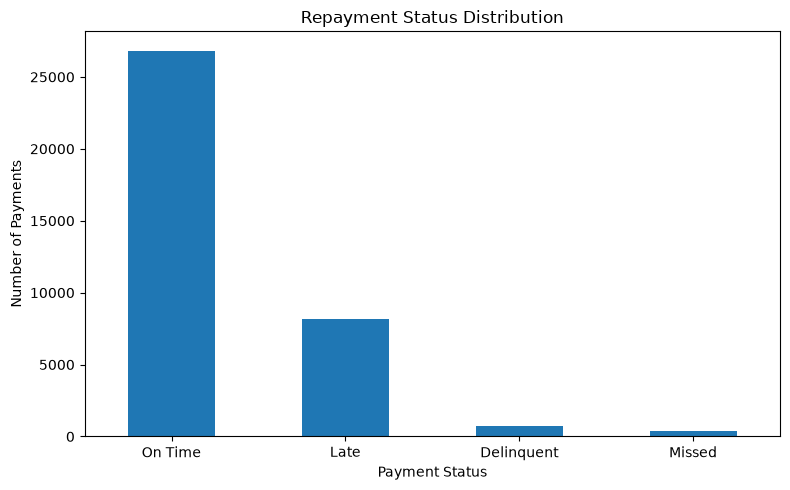

In [88]:
import matplotlib.pyplot as plt

status_counts = loan_payments["payment_status"].value_counts()

plt.figure(figsize=(8, 5))

status_counts.plot(kind="bar")

plt.title("Repayment Status Distribution")
plt.xlabel("Payment Status")
plt.ylabel("Number of Payments")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 11. Default Comparison

## 1 - Create the analysis dataset

In [89]:
default_analysis = (
    loans_clean[
        [
            "loan_id",
            "borrower_id",
            "loan_amount",
            "default_flag"
        ]
    ]
    .merge(
        borrowers[
            [
                "borrower_id",
                "annual_income",
                "existing_debt",
                "credit_score"
            ]
        ],
        on="borrower_id",
        how="left"
    )
    .merge(
        credit_history[
            [
                "borrower_id",
                "credit_utilization"
            ]
        ],
        on="borrower_id",
        how="left"
    )
)

default_analysis.head()

,loan_id,borrower_id,loan_amount,default_flag,annual_income,existing_debt,credit_score,credit_utilization
0,L200001,B100922,128000,0,109100,28000,722,0.288
1,L200002,B100662,38100,0,47500,22300,660,0.344
2,L200003,B100405,99800,1,58600,68400,568,0.530
3,L200004,B100677,74100,0,48900,10200,699,0.431
4,L200005,B100589,320900,0,53600,27600,676,0.222


## 2 - Create Debt-to-Income Ratio

In [90]:
default_analysis["debt_ratio"] = (
    default_analysis["existing_debt"]
    / default_analysis["annual_income"]
)

## 3 - Compare the distributions

In [91]:
default_distribution = (
    default_analysis
    .groupby("default_flag")
    .agg(
        avg_credit_score=("credit_score", "mean"),
        avg_income=("annual_income", "mean"),
        avg_debt_ratio=("debt_ratio", "mean"),
        avg_utilization=("credit_utilization", "mean"),
        avg_loan_amount=("loan_amount", "mean")
    )
    .reset_index()
)

default_distribution

,default_flag,avg_credit_score,avg_income,avg_debt_ratio,avg_utilization,avg_loan_amount
0,0,690.980824,59869.105114,1.020700,0.289842,221393.181818
1,1,672.296675,59048.593350,1.088378,0.305031,244962.915601


## 4 - Plot the distributions

<Figure size 700x500 with 0 Axes>

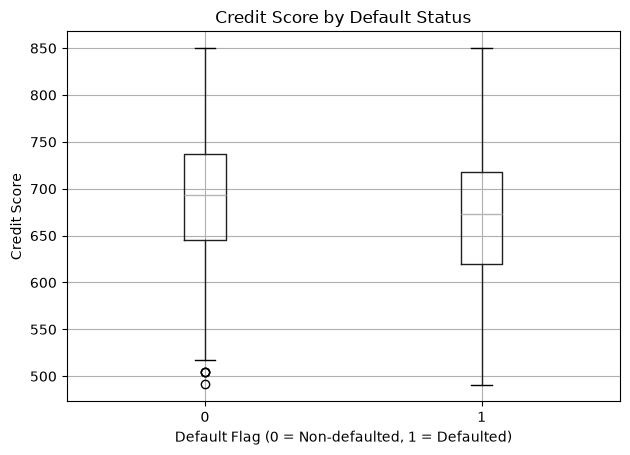

<Figure size 700x500 with 0 Axes>

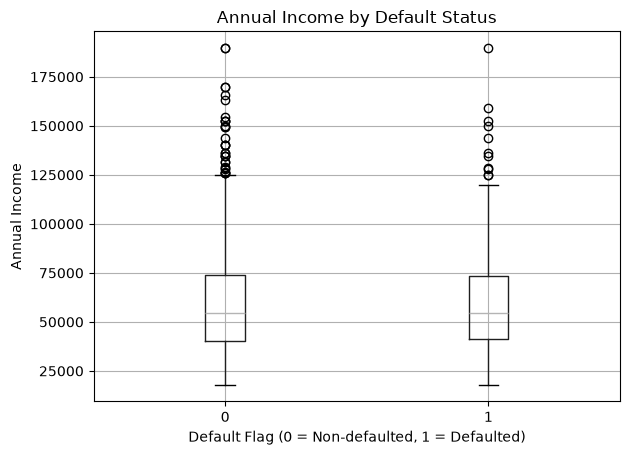

<Figure size 700x500 with 0 Axes>

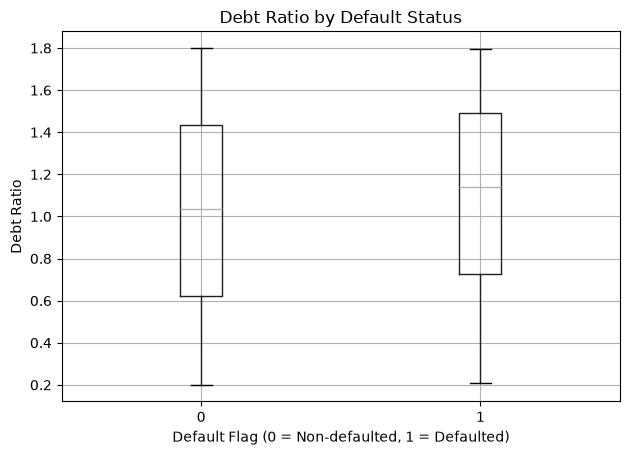

<Figure size 700x500 with 0 Axes>

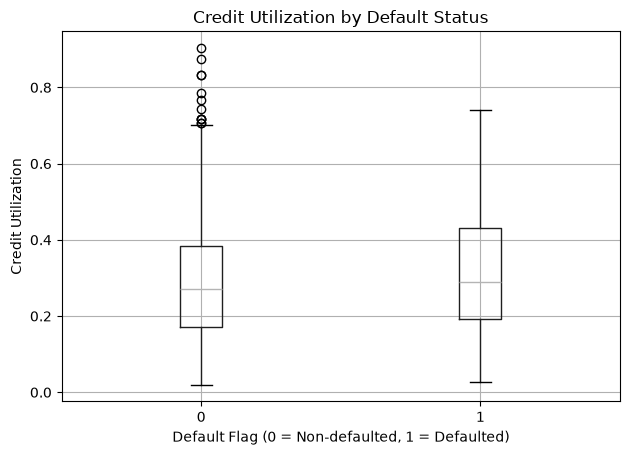

<Figure size 700x500 with 0 Axes>

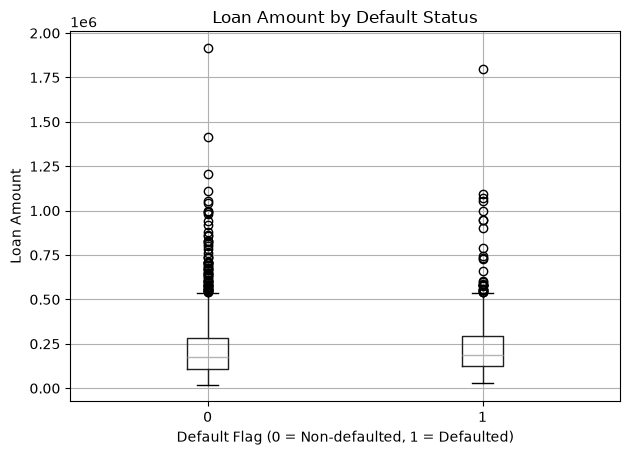

In [92]:
import matplotlib.pyplot as plt

variables = [
    "credit_score",
    "annual_income",
    "debt_ratio",
    "credit_utilization",
    "loan_amount"
]

for variable in variables:

    plt.figure(figsize=(7, 5))

    default_analysis.boxplot(
        column=variable,
        by="default_flag"
    )

    plt.title(f"{variable.replace('_', ' ').title()} by Default Status")
    plt.suptitle("")
    plt.xlabel("Default Flag (0 = Non-defaulted, 1 = Defaulted)")
    plt.ylabel(variable.replace("_", " ").title())

    plt.tight_layout()
    plt.show()

## Correlation Review

## 1 - Create the risk-variable dataset

In [93]:
risk_variables = default_analysis[
    [
        "credit_score",
        "annual_income",
        "existing_debt",
        "debt_ratio",
        "credit_utilization",
        "loan_amount"
    ]
]

## 2 - Calculate correlations

In [94]:
correlation_matrix = risk_variables.corr()

print("=== Correlation Matrix ===")
print(correlation_matrix)

=== Correlation Matrix ===
                    credit_score  annual_income  existing_debt  debt_ratio  \
credit_score            1.000000       0.031431      -0.003874   -0.017397   
annual_income           0.031431       1.000000       0.641850   -0.038928   
existing_debt          -0.003874       0.641850       1.000000    0.676196   
debt_ratio             -0.017397      -0.038928       0.676196    1.000000   
credit_utilization     -0.088348      -0.009192       0.006474    0.044359   
loan_amount             0.019871       0.022407       0.014997    0.000357   

                    credit_utilization  loan_amount  
credit_score                 -0.088348     0.019871  
annual_income                -0.009192     0.022407  
existing_debt                 0.006474     0.014997  
debt_ratio                    0.044359     0.000357  
credit_utilization            1.000000    -0.017427  
loan_amount                  -0.017427     1.000000  


## 3 - Visualize it

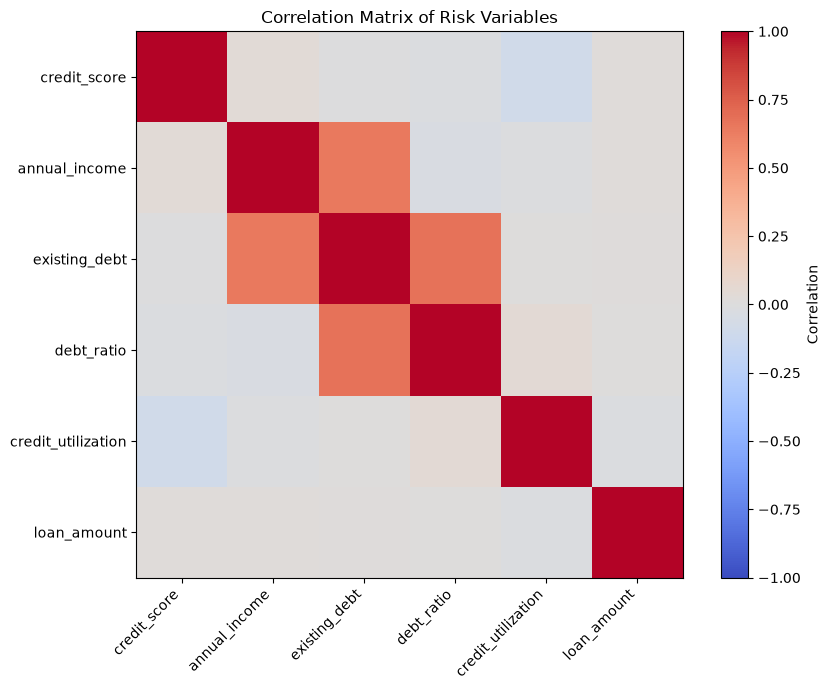

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Risk Variables")

plt.tight_layout()
plt.show()

## 13. Outlier Review

## 1 — Calculate IQR and identify outliers

In [96]:
print("=== Outlier Analysis using IQR ===")

variables = [
    "loan_amount",
    "annual_income",
    "existing_debt",
    "credit_utilization"
]

for variable in variables:

    Q1 = default_analysis[variable].quantile(0.25)
    Q3 = default_analysis[variable].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = default_analysis[
        (default_analysis[variable] < lower_bound) |
        (default_analysis[variable] > upper_bound)
    ]

    print(f"\n{variable}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Outlier Count:", len(outliers))

=== Outlier Analysis using IQR ===

loan_amount
Q1: 113750.0
Q3: 283500.0
IQR: 169750.0
Lower Bound: -140875.0
Upper Bound: 538125.0
Outlier Count: 95

annual_income
Q1: 40300.0
Q3: 74100.0
IQR: 33800.0
Lower Bound: -10400.0
Upper Bound: 124800.0
Outlier Count: 43

existing_debt
Q1: 32000.0
Q3: 80000.0
IQR: 48000.0
Lower Bound: -40000.0
Upper Bound: 152000.0
Outlier Count: 76

credit_utilization
Q1: 0.174
Q3: 0.39
IQR: 0.21600000000000003
Lower Bound: -0.15000000000000008
Upper Bound: 0.7140000000000001
Outlier Count: 12


## 2 - Inspect the actual outliers

In [97]:
loan_amount_outliers = default_analysis[
    (
        (default_analysis["loan_amount"] <
         default_analysis["loan_amount"].quantile(0.25)
         - 1.5 * (
             default_analysis["loan_amount"].quantile(0.75)
             - default_analysis["loan_amount"].quantile(0.25)
         ))
        |
        (default_analysis["loan_amount"] >
         default_analysis["loan_amount"].quantile(0.75)
         + 1.5 * (
             default_analysis["loan_amount"].quantile(0.75)
             - default_analysis["loan_amount"].quantile(0.25)
         ))
    )
]

print(loan_amount_outliers[
    ["loan_id", "borrower_id", "loan_amount",
     "annual_income", "existing_debt",
     "credit_utilization", "default_flag"]
].head(20))

     loan_id borrower_id  loan_amount  annual_income  existing_debt  \
46   L200048     B100562       639300          94800          70200   
63   L200065     B100879       711500          53100          15100   
114  L200116     B100526       810000          55400          31400   
128  L200130     B100607       791700          74800          89100   
161  L200163     B100553       582700          69700          96500   
180  L200182     B101190       552000          87000         125600   
184  L200186     B100654       543600          49900          65000   
186  L200188     B100638       733200          63300          12900   
188  L200190     B101165       543400          97300          52700   
191  L200193     B100294       726900          59600          50800   
201  L200203     B101046       544100          75100          33600   
236  L200238     B100783       593900          87300          23800   
251  L200253     B100892       569500         140100         232400   
337  L

In [98]:
loan_amount_outliers = default_analysis[
    default_analysis["loan_amount"] > 538125
]

print(
    loan_amount_outliers[
        [
            "loan_id",
            "borrower_id",
            "loan_amount",
            "annual_income",
            "existing_debt",
            "credit_score",
            "default_flag"
        ]
    ]
)

      loan_id borrower_id  loan_amount  annual_income  existing_debt  \
46    L200048     B100562       639300          94800          70200   
63    L200065     B100879       711500          53100          15100   
114   L200116     B100526       810000          55400          31400   
128   L200130     B100607       791700          74800          89100   
161   L200163     B100553       582700          69700          96500   
...       ...         ...          ...            ...            ...   
1710  L201712     B100925       552400          50900          11600   
1726  L201728     B100747       679100          19900          23600   
1727  L201729     B100593       565400          60700          60700   
1733  L201735     B100148       646500          60000          43400   
1798  L201800     B100193       948700          35100          44600   

      credit_score  default_flag  
46             733             0  
63             711             0  
114            671            

In [99]:
income_outliers = default_analysis[
    default_analysis["annual_income"] > 124800
]

print(
    income_outliers[
        [
            "borrower_id",
            "annual_income",
            "existing_debt",
            "credit_score",
            "credit_utilization",
            "loan_amount",
            "default_flag"
        ]
    ]
)

     borrower_id  annual_income  existing_debt  credit_score  \
19       B100232         127800          67200           757   
35       B100261         128600         140300           710   
52       B100014         134700         227900           776   
55       B100892         140100         232400           711   
87       B100373         129100          49200           702   
251      B100892         140100         232400           711   
393      B100581         152500         165000           595   
412      B100961         136000          50700           667   
414      B100205         126000         194600           654   
435      B100581         152500         165000           595   
455      B100261         128600         140300           710   
531      B100838         189600         134100           747   
589      B100778         159200          73500           616   
608      B100550         126000          28800           679   
615      B101028         169700         

In [100]:
debt_outliers = default_analysis[
    default_analysis["existing_debt"] > 152000
]

print(
    debt_outliers[
        [
            "borrower_id",
            "annual_income",
            "existing_debt",
            "credit_score",
            "credit_utilization",
            "loan_amount",
            "default_flag"
        ]
    ]
)

     borrower_id  annual_income  existing_debt  credit_score  \
17       B100585         110000         159500           771   
29       B100791         110100         156400           729   
52       B100014         134700         227900           776   
55       B100892         140100         232400           711   
59       B101102          90100         156600           713   
...          ...            ...            ...           ...   
1672     B100231         102400         173500           674   
1690     B100002         189600         157000           762   
1745     B100794         103600         168600           690   
1755     B100217          90100         152500           595   
1768     B101060         117900         209600           685   

      credit_utilization  loan_amount  default_flag  
17                 0.287       231400             0  
29                 0.337       394800             0  
52                 0.251        82500             0  
55             

In [101]:
utilization_outliers = default_analysis[
    default_analysis["credit_utilization"] > 0.714
]

print(
    utilization_outliers[
        [
            "borrower_id",
            "annual_income",
            "existing_debt",
            "credit_score",
            "credit_utilization",
            "loan_amount",
            "default_flag"
        ]
    ]
)

     borrower_id  annual_income  existing_debt  credit_score  \
106      B100745         108700         153600           660   
134      B100097          48000          74900           816   
155      B100588          55300          70500           580   
237      B100321         102800         113400           579   
403      B100321         102800         113400           579   
428      B100097          48000          74900           816   
510      B100143          67100          49900           662   
673      B101141          42300          52300           632   
681      B100443          53400          16000           813   
831      B100004          33100          50700           664   
926      B100314          57300          51400           789   
1523     B100439          52200          39300           532   

      credit_utilization  loan_amount  default_flag  
106                0.717       126400             0  
134                0.832       304100             0  
155  

## 14. Cohort Analysis

## 1 - Create the disbursement cohort

In [102]:
loans_clean["disbursement_cohort"] = (
    loans_clean["disbursement_date"]
    .dt.to_period("M")
    .astype(str)
)

loans_clean[[
    "loan_id",
    "disbursement_date",
    "disbursement_cohort",
    "default_flag"
]].head()

,loan_id,disbursement_date,disbursement_cohort,default_flag
0,L200001,2025-02-26,2025-02,0
1,L200002,2025-01-13,2025-01,0
2,L200003,2025-04-17,2025-04,1
3,L200004,2025-10-24,2025-10,0
4,L200005,2024-06-07,2024-06,0


In [103]:
cohort_analysis = (
    loans_clean
    .groupby("disbursement_cohort")
    .agg(
        loan_count=("loan_id", "nunique"),
        total_exposure=("loan_amount", "sum"),
        default_count=("default_flag", "sum")
    )
    .reset_index()
)

cohort_analysis["default_rate"] = (
    cohort_analysis["default_count"]
    / cohort_analysis["loan_count"]
    * 100
)

cohort_analysis

,disbursement_cohort,loan_count,total_exposure,default_count,default_rate
0,2024-01,57,12436700,15,26.315789
1,2024-02,93,20992800,15,16.129032
2,2024-03,75,18885900,14,18.666667
3,2024-04,73,16818100,14,19.178082
4,2024-05,59,16243300,15,25.423729
5,2024-06,89,20496500,13,14.606742
6,2024-07,78,16459300,24,30.769231
7,2024-08,72,14244100,13,18.055556
8,2024-09,86,21358200,20,23.255814
9,2024-10,75,15794400,22,29.333333


## Plot cohort default rates

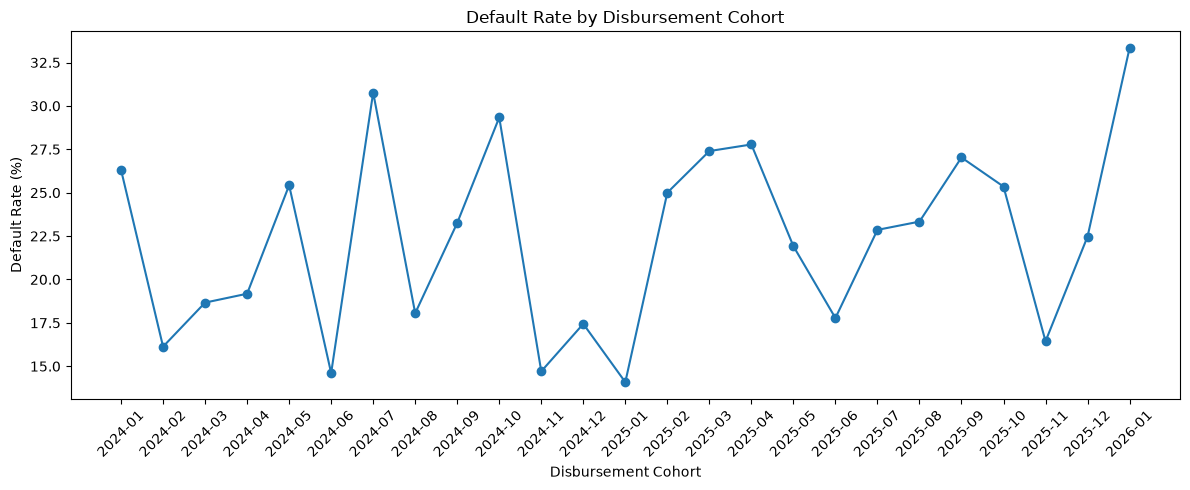

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    cohort_analysis["disbursement_cohort"],
    cohort_analysis["default_rate"],
    marker="o"
)

plt.title("Default Rate by Disbursement Cohort")
plt.xlabel("Disbursement Cohort")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 15. Visualization

## 1. Monthly Loan Exposure

In [105]:
monthly_exposure = (
    loans_clean
    .groupby(
        loans_clean["disbursement_date"].dt.to_period("M")
    )
    .agg(
        total_exposure=("loan_amount", "sum")
    )
    .reset_index()
)

monthly_exposure["disbursement_date"] = (
    monthly_exposure["disbursement_date"].astype(str)
)

monthly_exposure.head()

,disbursement_date,total_exposure
0,2024-01,12436700
1,2024-02,20992800
2,2024-03,18885900
3,2024-04,16818100
4,2024-05,16243300


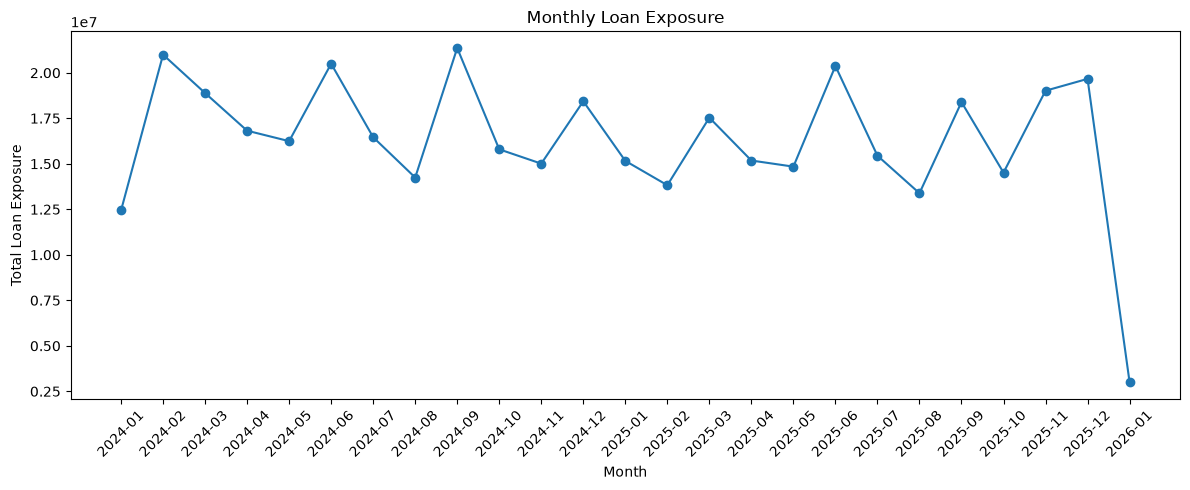

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_exposure["disbursement_date"],
    monthly_exposure["total_exposure"],
    marker="o"
)

plt.title("Monthly Loan Exposure")
plt.xlabel("Month")
plt.ylabel("Total Loan Exposure")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Default Rate by Credit Score Band

In [107]:
default_analysis["credit_score_band"] = pd.cut(
    default_analysis["credit_score"],
    bins=[0, 579, 669, 739, 799, 850],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

In [108]:
score_band_analysis = (
    default_analysis
    .groupby("credit_score_band", observed=False)
    .agg(
        loan_count=("loan_id", "nunique"),
        default_count=("default_flag", "sum")
    )
    .reset_index()
)

score_band_analysis["default_rate"] = (
    score_band_analysis["default_count"]
    / score_band_analysis["loan_count"]
    * 100
)

score_band_analysis

,credit_score_band,loan_count,default_count,default_rate
0,Poor,102,28,27.450980
1,Fair,588,161,27.380952
2,Good,710,133,18.732394
3,Very Good,320,57,17.812500
4,Excellent,79,12,15.189873


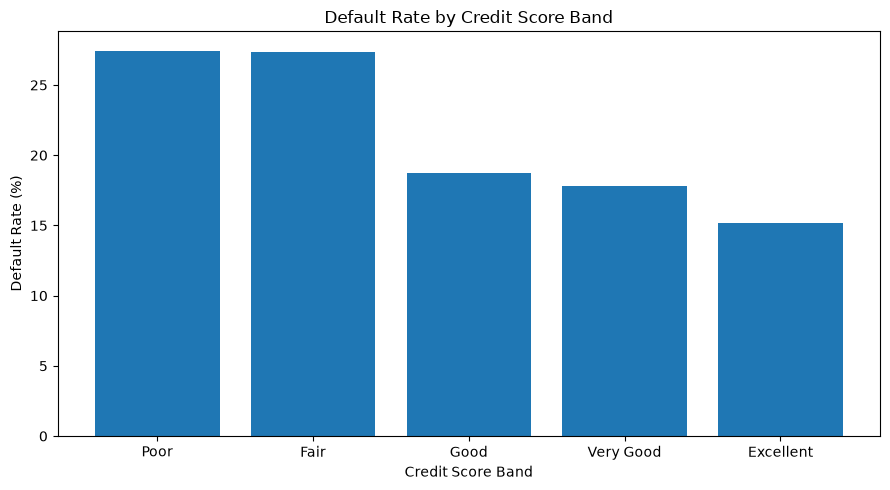

In [109]:
plt.figure(figsize=(9, 5))

plt.bar(
    score_band_analysis["credit_score_band"].astype(str),
    score_band_analysis["default_rate"]
)

plt.title("Default Rate by Credit Score Band")
plt.xlabel("Credit Score Band")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()

## 3. Exposure by Loan Type

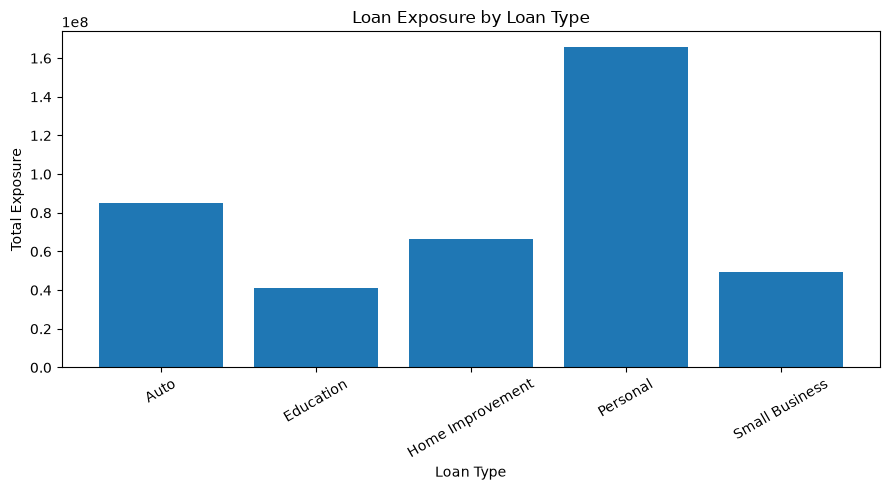

In [110]:
plt.figure(figsize=(9, 5))

plt.bar(
    loan_type_analysis["loan_type"],
    loan_type_analysis["total_exposure"]
)

plt.title("Loan Exposure by Loan Type")
plt.xlabel("Loan Type")
plt.ylabel("Total Exposure")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Payment Status Distribution

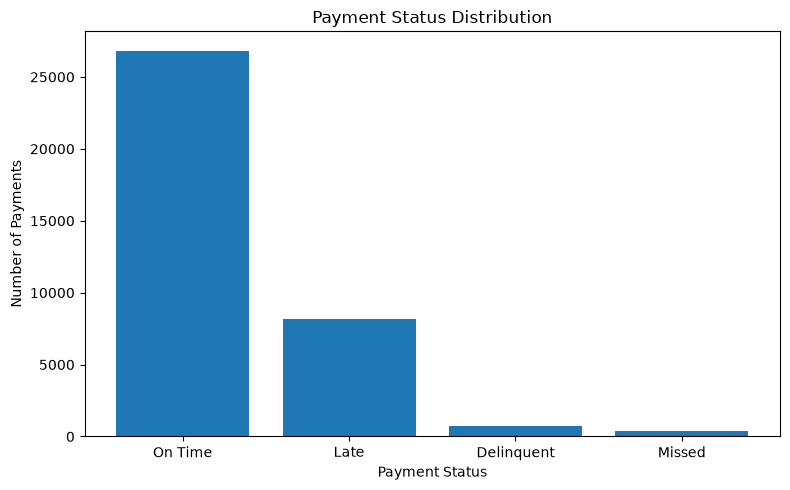

In [111]:
payment_status_counts = (
    loan_payments["payment_status"]
    .value_counts()
)

plt.figure(figsize=(8, 5))

plt.bar(
    payment_status_counts.index,
    payment_status_counts.values
)

plt.title("Payment Status Distribution")
plt.xlabel("Payment Status")
plt.ylabel("Number of Payments")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Credit Utilization vs Default Rate

In [112]:
default_analysis["utilization_band"] = pd.cut(
    default_analysis["credit_utilization"],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=[
        "0–25%",
        "25–50%",
        "50–75%",
        "75–100%"
    ],
    include_lowest=True
)

In [113]:
utilization_analysis = (
    default_analysis
    .groupby("utilization_band", observed=False)
    .agg(
        loan_count=("loan_id", "nunique"),
        default_count=("default_flag", "sum")
    )
    .reset_index()
)

utilization_analysis["default_rate"] = (
    utilization_analysis["default_count"]
    / utilization_analysis["loan_count"]
    * 100
)

utilization_analysis

,utilization_band,loan_count,default_count,default_rate
0,0–25%,817,166,20.318237
1,25–50%,770,178,23.116883
2,50–75%,206,47,22.815534
3,75–100%,6,0,0.000000


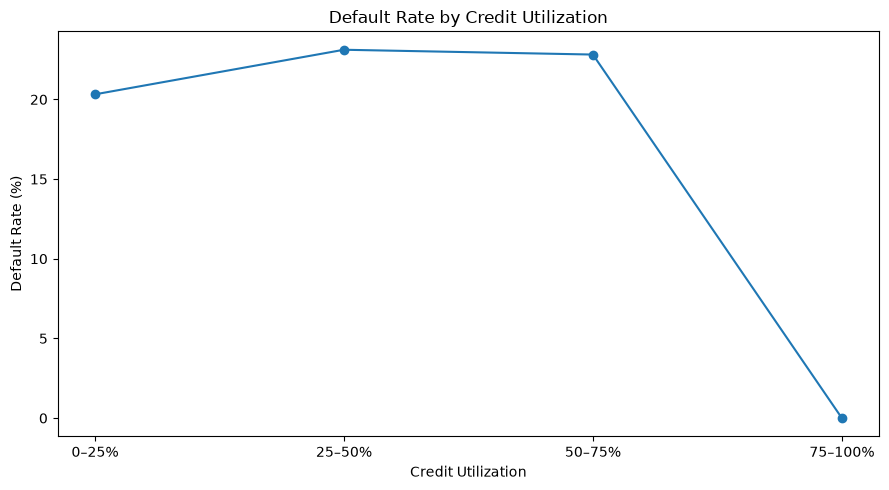

In [114]:
plt.figure(figsize=(9, 5))

plt.plot(
    utilization_analysis["utilization_band"].astype(str),
    utilization_analysis["default_rate"],
    marker="o"
)

plt.title("Default Rate by Credit Utilization")
plt.xlabel("Credit Utilization")
plt.ylabel("Default Rate (%)")

plt.tight_layout()
plt.show()